In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Форма набора данных и статистика

Этот набор данных исследует игровое поведение и его потенциальное влияние 
на 
режим сна и повседневную жизнь. Он включает демографические данные, 
продолжительность игрового процесса, предпочтительные жанры и показатели, 
связанные со сном.

Данный набор данных призван помочь изучать закономерности 
взаимосвязи между чрезмерным увлечением играми и факторами 
образа жизни, такими как качество и нарушения сна.

In [2]:
# Загружаем датасет из файла Gaming and Mental Health.csv что находитсся в папке data
df = pd.read_csv("data/Gaming and Mental Health.csv")
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [3]:
#Общая информация о датасете
print(f"Количество элементов (строк): {df.shape[0]}")  #
print(f"Количество признаков (столбцов): {df.shape[1]}")  #

Количество элементов (строк): 1000
Количество признаков (столбцов): 27


In [4]:
# Названия столбцов датасета
df.columns

Index(['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre',
       'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality',
       'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa',
       'work_productivity_score', 'mood_state', 'mood_swing_frequency',
       'withdrawal_symptoms', 'loss_of_other_interests',
       'continued_despite_problems', 'eye_strain', 'back_neck_pain',
       'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score',
       'face_to_face_social_hours_weekly', 'monthly_game_spending_usd',
       'years_gaming', 'gaming_addiction_risk_level'],
      dtype='object')

In [5]:
# Так как работатьт мы будем не со всем датасетом, а с частью
# Cоздадим новый датасет с выбранными столбцами
selected_columns = [
    "age", #Возраст участника
    "daily_gaming_hours", #Среднее количество часов, проведенных за играми в день
    "sleep_hours", # Часы сна участника
    "grades_gpa", # Средний балл успеваемости
    "back_neck_pain", # Боли в спине шее
    "gaming_addiction_risk_level", # Уровень риска
]
# Делаем копию изначального датасета, с выбранными столбцами
df_new = df[selected_columns].copy()
df_new.head()

,age,daily_gaming_hours,sleep_hours,grades_gpa,back_neck_pain,gaming_addiction_risk_level
0,17,11.1,3.7,1.25,False,Severe
1,21,3.0,7.2,3.75,False,Low
2,23,7.6,4.4,NaN,True,Severe
3,20,7.2,5.1,1.62,True,High
4,18,6.8,3.4,2.44,False,Moderate


In [6]:
# Провепка наличия пропущенных значений
# Считаем пропуски в каждом столбце
df_new.isnull().sum()

age                              0
daily_gaming_hours               0
sleep_hours                      0
grades_gpa                     246
back_neck_pain                   0
gaming_addiction_risk_level      0
dtype: int64

In [7]:
# Основные статистические показатели
# describe() автоматически находит mean, min, max, std для числовых признаков
df_new.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa
count,1000.000000,1000.000000,1000.000000,754.000000
mean,20.475000,6.151400,5.738100,2.518037
std,4.116105,2.867194,1.441213,0.872312
min,13.000000,0.500000,3.000000,1.010000
25%,18.000000,4.100000,4.800000,1.760000
50%,20.000000,6.000000,5.700000,2.530000
75%,22.000000,8.025000,6.600000,3.280000
max,35.000000,15.100000,9.000000,4.000000


In [8]:
# Удаляем строки, если в них есть пустые значения (NaN), чтобы данные были чистыми
# Всего было 1000 строк, 246 из них это null по столбцу grades_gpa 
# Видим что осталось 754 строки чиcтых данных
df_clean = df_new.dropna()
print(df_clean.shape)

(754, 6)


### Предварительный анализ и изучение свойств датаета df_new

In [9]:
# Выводим точные размеры получившейся таблицы (строк и столбцов)
print(f"Размерность отфильтрованного набора данных (строк, колонок): {df_clean.shape}")

Размерность отфильтрованного набора данных (строк, колонок): (754, 6)


In [10]:
# Отображаем первые 5 строк таблицы для визуального ознакомления со структурой данных
df_clean.head(5)

,age,daily_gaming_hours,sleep_hours,grades_gpa,back_neck_pain,gaming_addiction_risk_level
0,17,11.1,3.7,1.25,False,Severe
1,21,3.0,7.2,3.75,False,Low
3,20,7.2,5.1,1.62,True,High
4,18,6.8,3.4,2.44,False,Moderate
5,21,2.1,7.5,3.81,False,Low


In [11]:
# Проверяем типы данных в каждом столбце и ищем скрытые пропуски
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 754 entries, 0 to 998
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          754 non-null    int64  
 1   daily_gaming_hours           754 non-null    float64
 2   sleep_hours                  754 non-null    float64
 3   grades_gpa                   754 non-null    float64
 4   back_neck_pain               754 non-null    bool   
 5   gaming_addiction_risk_level  754 non-null    object 
dtypes: bool(1), float64(3), int64(1), object(1)
memory usage: 36.1+ KB


In [12]:
# Получаем базовые статистические характеристики для числовых признаков
# (среднее значение, стандартное отклонение, минимум, максимум и медиану)
df_clean.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa
count,754.000000,754.000000,754.000000,754.000000
mean,18.590186,6.154244,5.737798,2.518037
std,2.238848,2.782317,1.421376,0.872312
min,13.000000,0.500000,3.000000,1.010000
25%,17.000000,4.200000,4.900000,1.760000
50%,19.000000,6.000000,5.700000,2.530000
75%,20.000000,8.000000,6.600000,3.280000
max,22.000000,15.100000,9.000000,4.000000


Здесь можно заметить смещение опрошенных по возрасту. До этого максимальный возраст составлял 35 лет, а сейчас он составляет 22. Получается люди у которых отстутствует grades_gpa это работающие люди старше 22 лет. Проверим данную гипотезу

In [13]:
# Проверяем гипотезу: кто эти люди с пропусками GPA?

# Группа А: люди, у которых GPA отсутствует
age_with_nan_gpa = df_new[df_new['grades_gpa'].isnull()]['age']

# Группа Б: люди, у которых GPA заполнен
age_with_valid_gpa = df_new[df_new['grades_gpa'].notnull()]['age']

print("--- Статистика возраста для группы БЕЗ GPA (пропуски) ---")
print(age_with_nan_gpa.describe())

print("\n--- Статистика возраста для группы С УКАЗАННЫМ GPA ---")
print(age_with_valid_gpa.describe())

# Проверим минимальный возраст среди тех, у кого пропал GPA
print(f"\nМинимальный возраст человека без GPA: {age_with_nan_gpa.min()} лет")

--- Статистика возраста для группы БЕЗ GPA (пропуски) ---
count    246.000000
mean      26.252033
std        3.038779
min       23.000000
25%       24.000000
50%       26.000000
75%       28.000000
max       35.000000
Name: age, dtype: float64

--- Статистика возраста для группы С УКАЗАННЫМ GPA ---
count    754.000000
mean      18.590186
std        2.238848
min       13.000000
25%       17.000000
50%       19.000000
75%       20.000000
max       22.000000
Name: age, dtype: float64

Минимальный возраст человека без GPA: 23 лет


Видим что минимальный возраст это 23. значит 23 - 35 это категория  людей без gpa.

In [14]:
# Убираем столбец grades_gpa из выбраных
# Cоздадим новый датасет с выбранными столбцами
selected_all = [
    "age", #Возраст участника
    "daily_gaming_hours", #Среднее количество часов, проведенных за играми в день
    "sleep_hours", # Часы сна участника
    "back_neck_pain", # Боли в спине шее
    "gaming_addiction_risk_level", # Уровень риска
]
# Делаем копию изначального датасета, с выбранными столбцами
df_all = df[selected_all].copy()
df_all.head()

,age,daily_gaming_hours,sleep_hours,back_neck_pain,gaming_addiction_risk_level
0,17,11.1,3.7,False,Severe
1,21,3.0,7.2,False,Low
2,23,7.6,4.4,True,Severe
3,20,7.2,5.1,True,High
4,18,6.8,3.4,False,Moderate


In [15]:
print("Проверка пропусков:")
print(df_all.isnull().sum())
print(f"Размерность датасета: {df_all.shape}")

Проверка пропусков:
age                            0
daily_gaming_hours             0
sleep_hours                    0
back_neck_pain                 0
gaming_addiction_risk_level    0
dtype: int64
Размерность датасета: (1000, 5)


Как видим все строки были сохранены

In [16]:
# Проверка на полные дубликаты строк
duplicates_count = df_all.duplicated().sum()
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 11


In [17]:
df_all[df_all.duplicated()]

,age,daily_gaming_hours,sleep_hours,back_neck_pain,gaming_addiction_risk_level
300,22,3.8,5.4,False,Low
402,19,4.6,5.9,False,Low
406,18,10.4,4.7,True,Severe
433,18,3.8,5.2,False,Low
578,21,2.7,8.2,False,Low
671,19,4.0,6.9,False,Low
730,17,3.2,7.2,False,Low
830,22,6.4,5.4,False,Moderate
841,16,9.0,5.8,True,Severe
867,19,4.3,6.3,False,Low


In [18]:
df_all = df_all.drop_duplicates(keep='first').reset_index(drop=True)
print("Дубликаты успешно удалены!")
print(f"Новая размерность датасета: {df_all.shape}")

Дубликаты успешно удалены!
Новая размерность датасета: (989, 5)


In [19]:
# Создаем копию для проверки, чтобы не повредить df_all
df_outliers_check = df_all.copy()
# Выбираем столбцы по которым будет проводиться проверка на выбросы
numerical_features = ["daily_gaming_hours", "sleep_hours"]

print("Результаты анализа признаков на наличие выбросов (метод IQR):")
print("-" * 60)

for col in numerical_features:
    # Вычисляем первый (25%) и третий (75%) квартили
    Q1 = df_outliers_check[col].quantile(0.25)
    Q3 = df_outliers_check[col].quantile(0.75)
    # Находим межквартильный размах
    IQR = Q3 - Q1
    # Определяем математические границы для фильтрации выбросов
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Идентифицируем строки, которые выходят за рамки этих границ
    outliers_detected = df_outliers_check[
        (df_outliers_check[col] < lower_bound)
        | (df_outliers_check[col] > upper_bound)
    ]
    print(f"Признак '{col}':")
    print(f"  -> Допустимый интервал: от {lower_bound:.1f} до {upper_bound:.1f}")
    print(f"  -> Выявлено аномальных значений: {len(outliers_detected)}")
    print("-" * 60)

Результаты анализа признаков на наличие выбросов (метод IQR):
------------------------------------------------------------
Признак 'daily_gaming_hours':
  -> Допустимый интервал: от -1.6 до 13.9
  -> Выявлено аномальных значений: 6
------------------------------------------------------------
Признак 'sleep_hours':
  -> Допустимый интервал: от 2.1 до 9.3
  -> Выявлено аномальных значений: 0
------------------------------------------------------------


In [20]:
# Удаляем 6 аномальных строк, превышающих верхнюю границу IQR (13.9)
df_all = df_all[df_all["daily_gaming_hours"] <= 13.9].copy()

print(
    f"Размер выборки после удаления статистических выбросов: {df_all.shape}"
)

Размер выборки после удаления статистических выбросов: (983, 5)


In [21]:
df_all.describe()

,age,daily_gaming_hours,sleep_hours
count,983.000000,983.000000,983.000000
mean,20.472024,6.110987,5.743337
std,4.116800,2.801026,1.443566
min,13.000000,0.500000,3.000000
25%,18.000000,4.150000,4.800000
50%,20.000000,6.000000,5.700000
75%,22.000000,8.000000,6.600000
max,35.000000,13.900000,9.000000


In [22]:
# Отдельно смотрим распределение нашего целевого (категориального) признака
# Это покажет, сколько геймеров попало в каждую группу риска
df_all['gaming_addiction_risk_level'].value_counts()

gaming_addiction_risk_level
Low         506
Moderate    187
High        152
Severe      138
Name: count, dtype: int64

### Изучение распределения признаков

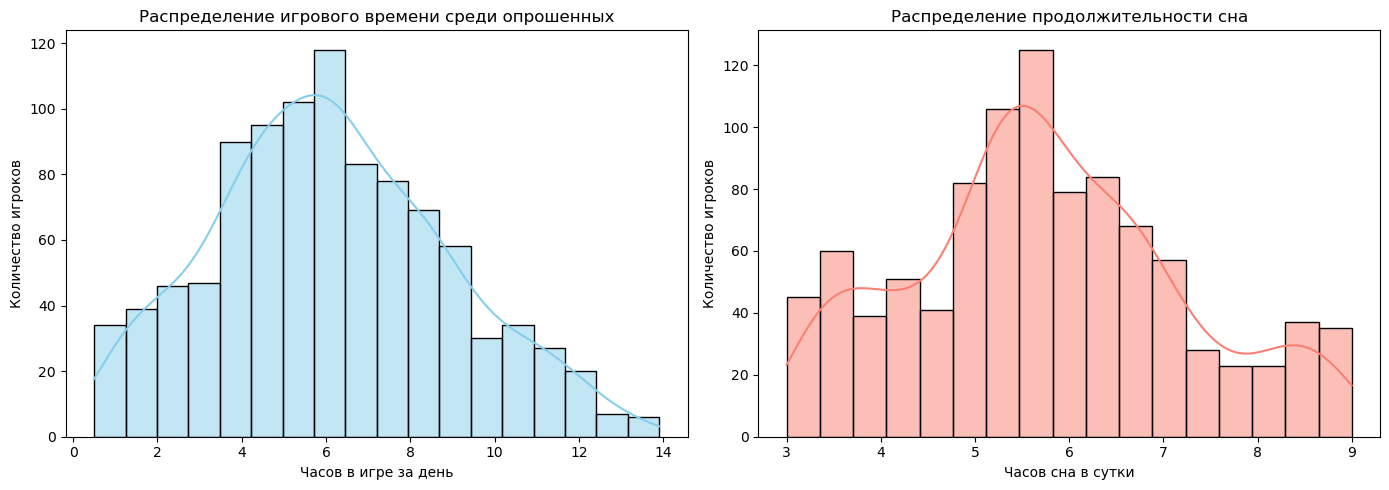

In [23]:
# Создаем общее полотно для двух графиков распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График А: Распределение ежедневных игровых часов
sns.histplot(data=df_all, x="daily_gaming_hours", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Распределение игрового времени среди опрошенных")
axes[0].set_xlabel("Часов в игре за день")
axes[0].set_ylabel("Количество игроков")

# График Б: Распределение часов сна
sns.histplot(data=df_all, x="sleep_hours", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Распределение продолжительности сна")
axes[1].set_xlabel("Часов сна в сутки")
axes[1].set_ylabel("Количество игроков")


plt.tight_layout()
plt.show()

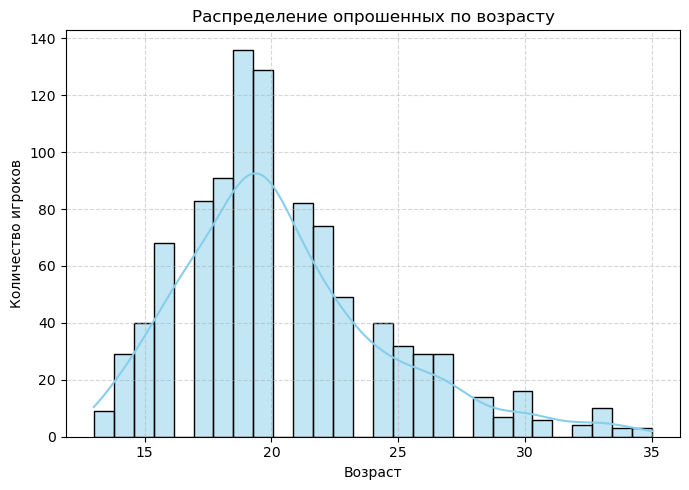

In [24]:
# Создаем полотно для одного графика распределения возрастов
fig, ax = plt.subplots(figsize=(7, 5))

# Строим график распределения возрастов
sns.histplot(data=df_all, x="age", kde=True, ax=ax, color="skyblue")

# Настраиваем заголовки и подписи осей
ax.set_title("Распределение опрошенных по возрасту", fontsize=12)
ax.set_xlabel("Возраст", fontsize=10)
ax.set_ylabel("Количество игроков", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)  # Добавим аккуратную сетку

plt.tight_layout()
plt.show()

### Построение проекций

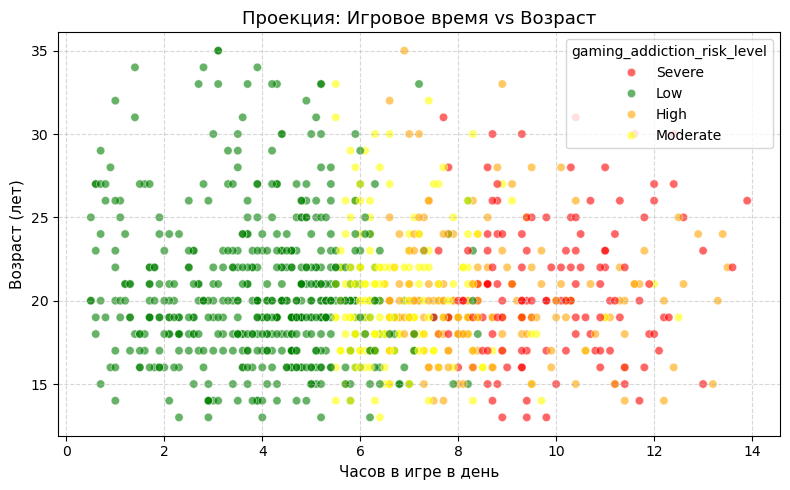

In [25]:
# Проекция №1: Игровое время VS Возраст
# Создаем полотно
plt.figure(figsize=(8, 5))

# Набор цветов, соответствующий категориям в датасете
palette_colors = {"Low": "green", "Moderate": "yellow",
    "High": "orange", "Severe": "red",
}
# Строим диаграмму рассеяния для игрового времени и возраста
sns.scatterplot(data=df_all,  x="daily_gaming_hours",
    y="age", hue="gaming_addiction_risk_level",  # Окрашиваем точки по уровню риска
    palette=palette_colors, alpha=0.6,  # Прозрачность для отслеживания плотности скопления точек
)
# Оформление графика
plt.title("Проекция: Игровое время vs Возраст", fontsize=13)
plt.xlabel("Часов в игре в день", fontsize=11)
plt.ylabel("Возраст (лет)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
# Отображение
plt.tight_layout()
plt.show()

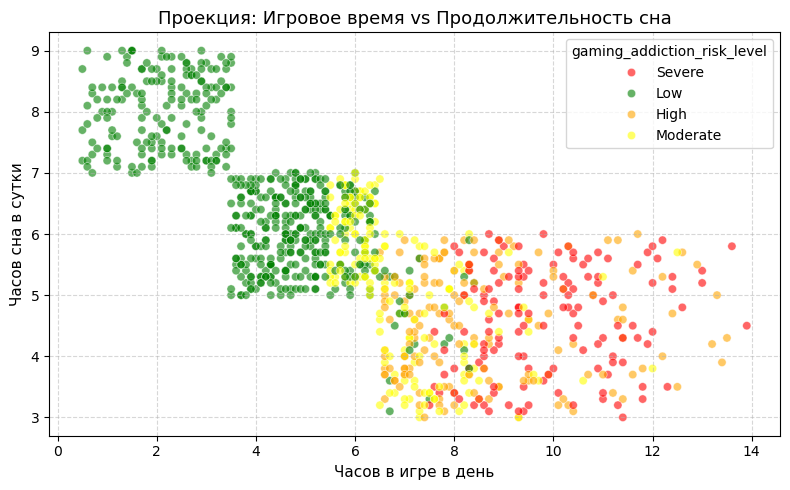

In [26]:
# Проекция №2: Игровое время VS Время сна

# Создаем полотно
plt.figure(figsize=(8, 5))

# Набор цветов, соответствующий категориям в датасете
palette_colors = { "Low": "green", "Moderate": "yellow",
    "High": "orange","Severe": "red",
}
# Строим диаграмму рассеяния для игрового времени и часов сна
sns.scatterplot( data=df_all, x="daily_gaming_hours",
    y="sleep_hours", hue="gaming_addiction_risk_level",  # Окрашиваем точки по уровню риска
    palette=palette_colors, alpha=0.6,
)
# Оформление графика
plt.title(
    "Проекция: Игровое время vs Продолжительность сна",
    fontsize=13,
)
plt.xlabel("Часов в игре в день", fontsize=11)
plt.ylabel("Часов сна в сутки", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
# Отображение
plt.tight_layout()
plt.show()

### Матрица попарного распределения

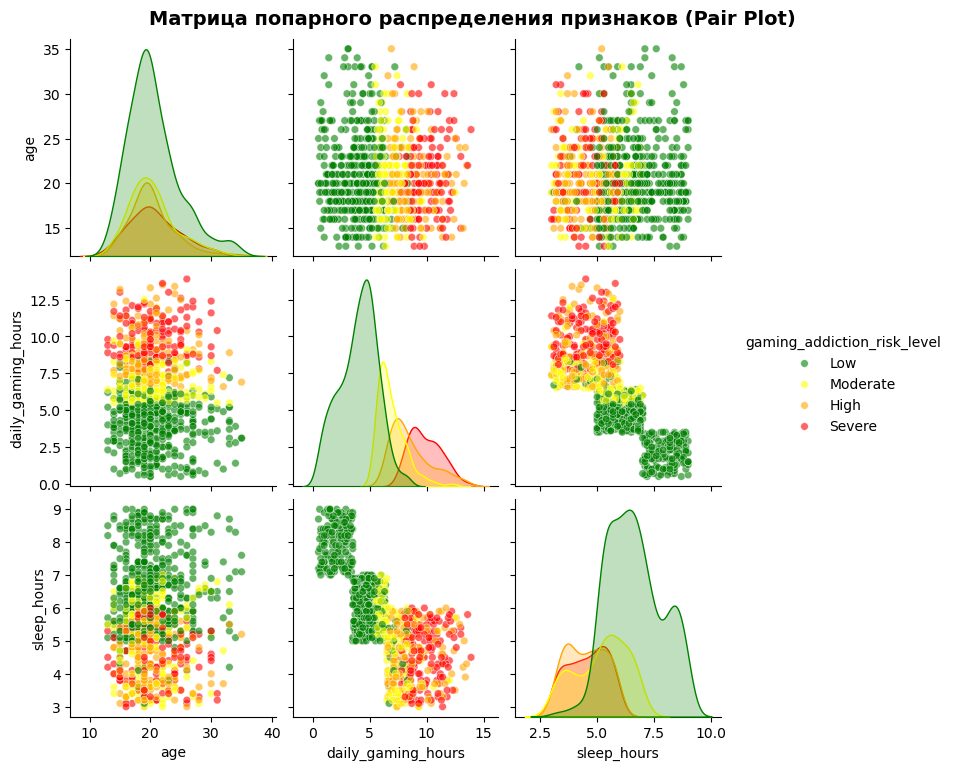

In [27]:
# Выбираем ключевые числовые признаки и целевую переменную для группировки
pair_features = ["age", "daily_gaming_hours", "sleep_hours", "gaming_addiction_risk_level"]
# Определяем правильный порядок отображения категорий
risk_order = [r for r in ["Low", "Moderate", "High", "Severe"]
    if r in df_all["gaming_addiction_risk_level"].unique()
]
# Строим матрицу попарного распределения
grid = sns.pairplot(
    data=df_all[pair_features], 
    hue="gaming_addiction_risk_level", 
    hue_order=risk_order,
    palette=palette_colors,
    diag_kind="kde",      # По диагонали строим сглаженные графики плотности распределения
    kind="scatter",       # Вне диагонали — диаграммы рассеяния (проекции)
    plot_kws={"alpha": 0.6, "s": 30}, # Настройки прозрачности и размера точек
    height=2.5            # Размер каждого отдельного подграфика
)

# Добавляем общий заголовок для всей матрицы графиков
grid.fig.suptitle("Матрица попарного распределения признаков (Pair Plot)", y=1.02, fontsize=14, fontweight="bold")

plt.show()

In [28]:
# Создаем копию датасета, чтобы работать с числами
df_numeric = df_all.copy()
# Переводим признак back_neck_pain в строковый формат нижнего регистра и сопоставляем значения
df_numeric["back_neck_pain"] = (
    df_numeric["back_neck_pain"]
    .astype(str)
    .str.lower()
    .map({"true": 1, "false": 0})
)
# Кодируем целевой признак уровня зависимости
risk_mapping = {"Low": 0, "Moderate": 1, "Severe": 2, "High": 3}
df_numeric["gaming_addiction_risk_level"] = df_numeric[
    "gaming_addiction_risk_level"
].map(risk_mapping)

### Анализ связи игрового времени и физической боли

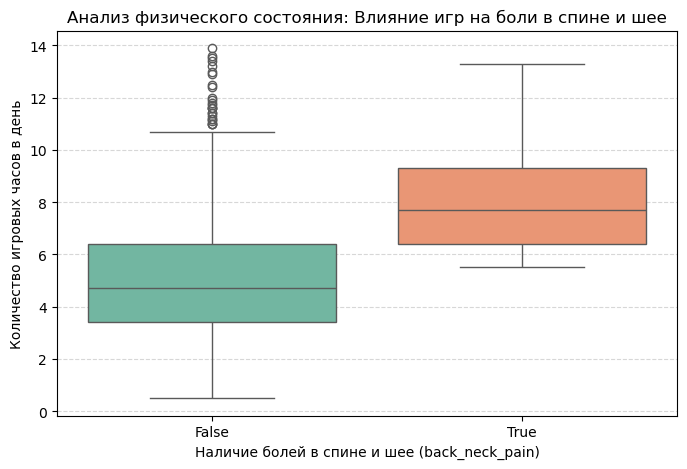

In [29]:
plt.figure(figsize=(8, 5))

# Исправлено в соответствии с предупреждением: 
# добавляем hue="back_neck_pain" и отключаем дублирующую легенду legend=False
sns.boxplot(data=df_all,  x="back_neck_pain", 
    y="daily_gaming_hours", hue="back_neck_pain",  # Явно указываем, что красим ящики по группам боли
    palette="Set2", legend=False           # Убираем лишнюю легенду, так как подписи есть на оси X
)
# Настройка подписей и заголовка
plt.title("Анализ физического состояния: Влияние игр на боли в спине и шее", fontsize=12)
plt.xlabel("Наличие болей в спине и шее (back_neck_pain)", fontsize=10)
plt.ylabel("Количество игровых часов в день", fontsize=10)
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
# Отображение графика
plt.show()

### Тепловая карта корреляции

In [30]:
df_all['gaming_addiction_risk_level'].value_counts()

gaming_addiction_risk_level
Low         506
Moderate    187
High        152
Severe      138
Name: count, dtype: int64

In [31]:
df_numeric['gaming_addiction_risk_level'].value_counts()

gaming_addiction_risk_level
0    506
1    187
3    152
2    138
Name: count, dtype: int64

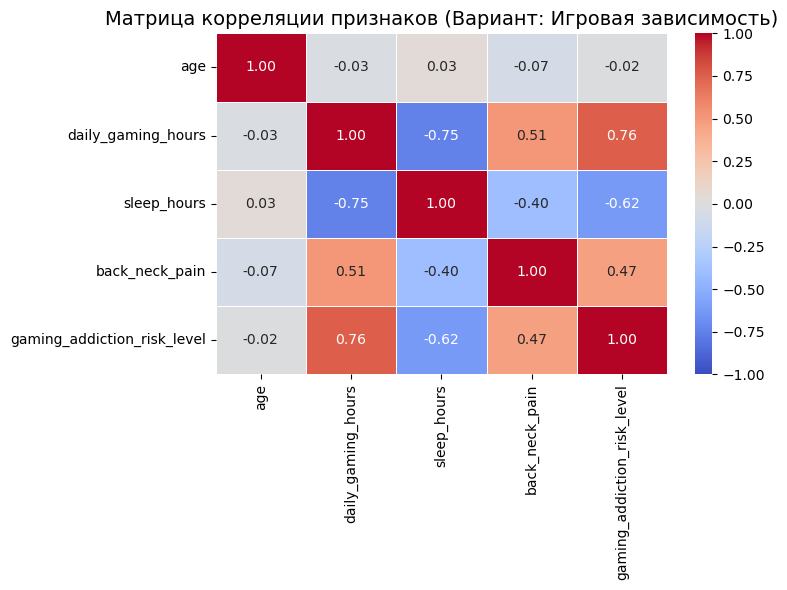

In [32]:
# Рассчитываем корреляцию Пирсона
corr_matrix = df_numeric.corr()
# Визуализируем матрицу корреляции
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True,
    cmap="coolwarm",fmt=".2f",
    linewidths=0.5, vmin=-1, vmax=1,
)
plt.title("Матрица корреляции признаков (Вариант: Игровая зависимость)", fontsize=14)
plt.tight_layout()
plt.show()

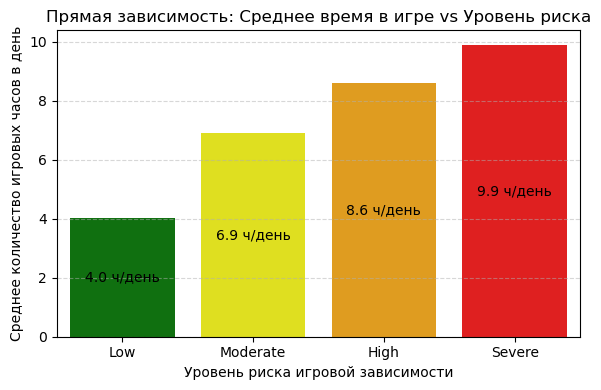

In [33]:
# Зависимость игровых часов от цровня риска
# Устанавливаем размер для одного конкретного графика
plt.figure(figsize=(6, 4))
# Строгая палитра цветов для уровней риска
palette_colors = {"Low": "green","Moderate": "yellow",
    "High": "orange", "Severe": "red",
}
# Определяем правильный порядок отображения категорий
risk_order = [r for r in ["Low", "Moderate", "High", "Severe"]
    if r in df_all["gaming_addiction_risk_level"].unique()
]
# Столбчатая диаграмма показывает, как меняется среднее число часов
ax = sns.barplot(data=df_all, x="gaming_addiction_risk_level",
    y="daily_gaming_hours",
    hue="gaming_addiction_risk_level", order=risk_order,
    palette=palette_colors, errorbar=None,  # Убираем усы погрешности
)
# Добавляем текстовые метки со средними значениями на столбцы
for container in ax.containers:
    ax.bar_label(container,fmt="%.1f ч/день",
        label_type="center",color="black",
    )
plt.title("Прямая зависимость: Среднее время в игре vs Уровень риска", fontsize=12)
plt.xlabel("Уровень риска игровой зависимости", fontsize=10)
plt.ylabel("Среднее количество игровых часов в день", fontsize=10)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()